# Stomata size, density and water-use efficiency in *Arabidopsis thaliana* — statistical reproduction

**Paper:** Dittberner H., Korte A., Mettler-Altmann T., Weber A.P.M., Monroe G., de Meaux J. (2018)
*Natural variation in stomata size contributes to the local adaptation of water-use efficiency in Arabidopsis thaliana.*
Molecular Ecology 27(20):4052–4065. [PMC7611081](https://pmc.ncbi.nlm.nih.gov/articles/PMC7611081/)

**Scope (statistical demonstration on the full published tables):** reproduce the paper's
phenotype/genetic-architecture **subsection** — (1) broad-sense heritability of stomata size and density,
(2) trait relationships among stomata size, density and δ¹³C, and (3) the climatic-PC regression
(GLM) of phenotypes on climate of origin — using the authors' **Appendix S2 R code** with
**input files rebuilt from the published tables** (`Suppl_Table1.csv`, `Suppl_Table2.csv` on Dryad).
The author chunks that require unpublished working files (raw imaging controls, 1001-Genomes genotype
matrices, GWAS alleles, FST input) are skipped and reported — see the chunk-selection table.

**ADAPTED DEMONSTRATION disclosure:** the authors did not publish this Colab implementation. Their R
chunk code is run verbatim wherever the published tables provide the inputs; the few disclosed edits
(input paths, column renames, removed unavailable covariates) are listed beside the relevant cells.
The executed subset and listed checks were validated, but untested behavior is not guaranteed.

**日本語での実行範囲:** このノートブックは、Dryad の公開表 (`Suppl_Table1.csv`, `Suppl_Table2.csv`) を
著者の付録S2 Rコード用の入力に変換し、著者コードを可能な限りそのまま実行して、(1) 気孔サイズ・密度の
広義遺伝率、(2) 形質間の関係、(3) 気候主成分に対するGLMを再現します。遺伝子型行列・GWAS・画像検証データ
を必要とするチャンクはスキップし、その理由を表に示します。著者コードへの最小限の変更はすべて明示します。

**Runtime:** a standard **CPU** runtime is recommended and sufficient — pure statistics, no GPU.
Select *Runtime → Change runtime type → CPU*, then *Runtime → Run all*.
Expected wall time ≈ 15–30 minutes (R package installation dominates); total download < 10 MB.


## 1. Environment setup

Checks Python and R availability. Colab CPU images ship `Rscript`; if missing, `r-base` is installed.
**Setup（日本語）:** Python と R (`Rscript`) の有無を確認し、必要なら `r-base` をインストールします。

In [ ]:
import os, sys, shutil, subprocess

print("Python:", sys.version.split()[0])
rscript = shutil.which("Rscript")
if rscript is None:
    print("Rscript not found -> installing r-base (this can take a few minutes)...")
    subprocess.run(
        ["bash", "-c", "apt-get update -qq && apt-get install -y -qq r-base > /tmp/r-install.log 2>&1; tail -2 /tmp/r-install.log"],
        check=True,
    )
    rscript = shutil.which("Rscript")
assert rscript is not None, "R is required for the author-code path"
r_ver = subprocess.run([rscript, "--version"], capture_output=True, text=True).stdout.splitlines()[0]
print("Rscript:", rscript, "->", r_ver)

Python: 3.13.15
Rscript: /usr/bin/Rscript -> Rscript (R) version 4.6.1 (2026-06-24)


## 2. Acquire the authors' published data and Appendix S2 (Colab-side downloads only)

All files come from the paper's Dryad repository (`doi:10.5061/dryad.n068q74`; file names, sizes and
MD5 digests verified via the Dryad API on 2026-10-02) and the PMC supplementary package. Byte
integrity of the two CSV tables is checked against the Dryad API digests:

- `Suppl_Table1.csv` (geography/climate per accession) — MD5 `8da13199c45cde1aff7857c15cd5aafb`, 48,973 bytes
- `Suppl_Table2.csv` (phenotypes per plant) — MD5 `949cfeaa724f73e3455c1f69428ab045`, 85,825 bytes
- Appendix S2 = `mec14838-sup-0005-documents2.html` (knitted R Markdown, "R Markdown output documenting
  the statistical analysis") inside the PMC supplement zip.

The Dryad `file_stream` endpoint is protected by a browser challenge for non-interactive clients, so the
Europe PMC supplementary-file service is the primary route; the Dryad endpoint is kept as a fallback.

**データ取得（日本語）:** Dryad/PMC から著者公開の表と付録S2をColab内でダウンロードし、
MD5で完全性を確認します。

In [ ]:
import hashlib, io, os, pathlib, shutil, urllib.request, zipfile

WORK = pathlib.Path("/content/stomata_repro"); WORK.mkdir(exist_ok=True)
DATA = WORK / "data"; DATA.mkdir(exist_ok=True)

EXPECTED_MD5 = {
    "Suppl_Table1.csv": "8da13199c45cde1aff7857c15cd5aafb",
    "Suppl_Table2.csv": "949cfeaa724f73e3455c1f69428ab045",
}

def md5sum(path):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

def fetch(url, dest, timeout=600):
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0 (X11; Linux x86_64) Colab-notebook-reproduction"})
    with urllib.request.urlopen(req, timeout=timeout) as r, open(dest, "wb") as f:
        shutil.copyfileobj(r, f)
    return dest

def is_zip(path):
    return zipfile.is_zipfile(path)

def safe_extract(zp, dest):
    dest.mkdir(exist_ok=True)
    with zipfile.ZipFile(zp) as z:
        for name in z.namelist():
            target = (dest / name).resolve()
            if not str(target).startswith(str(dest.resolve())):
                raise RuntimeError(f"unsafe zip member: {name}")
        z.extractall(dest)

SUPPL = WORK / "supplement"

# --- Supplement zip: authorized public routes, tried in order ---
ZIP_ROUTES = [
    ("europepmc-supplementaryFiles", "https://www.ebi.ac.uk/europepmc/webservices/rest/PMC7611081/supplementaryFiles"),
    ("pmc-instance-bin", "https://pmc.ncbi.nlm.nih.gov/articles/instance/7611081/bin/EMS127292-supplement-Supplementary_Information.zip"),
]
suppl_ok = False
for label, url in ZIP_ROUTES:
    zp = WORK / (label + ".zip")
    try:
        print("Trying route:", label)
        fetch(url, zp)
        print("  bytes:", zp.stat().st_size)
        if is_zip(zp):
            safe_extract(zp, SUPPL)
            suppl_ok = True
            print("  -> extracted OK from", label)
            break
        else:
            print("  -> not a zip; first bytes:", open(zp, "rb").read(120))
    except Exception as e:
        print("  -> failed:", e)
assert suppl_ok, ("No authorized route produced a valid supplement zip; refusing to fabricate data. "
                  "Tried: " + ", ".join(l for l, _ in ZIP_ROUTES))

# Recursively extract nested zips (e.g. Europe PMC wraps the PMC supplement zip)
for depth in range(3):
    nested = [p for p in SUPPL.rglob("*.zip") if not p.with_suffix(".extracted").exists()]
    if not nested:
        break
    for p in nested:
        print("Extracting nested zip:", p.name, p.stat().st_size, "bytes")
        safe_extract(p, p.parent / (p.stem + "_extracted"))
        p.with_suffix(".extracted").touch()

suppl_files = sorted(str(p.relative_to(SUPPL)) for p in SUPPL.rglob("*") if p.is_file())
print("Supplement contents (%d files):" % len(suppl_files))
for s in suppl_files:
    print("  ", s)

# --- CSVs: PMC/Wiley supplement copies and/or Dryad, byte-checked against the Dryad digests ---
WILEY_ALIAS = {"Suppl_Table1.csv": "*tables1.csv", "Suppl_Table2.csv": "*tables2.csv"}
for name, digest in EXPECTED_MD5.items():
    ok = False
    found = list(SUPPL.rglob(name))
    for p in found:
        if md5sum(p) == digest:
            shutil.copy(p, DATA / name)
            print(f"{name}: exact-name supplement copy, MD5 OK ({digest})")
            ok = True
    if not ok:
        import fnmatch
        wiley = [p for p in SUPPL.rglob("*.csv") if fnmatch.fnmatch(p.name, WILEY_ALIAS[name])]
        if wiley:
            got = md5sum(wiley[0])
            shutil.copy(wiley[0], DATA / name)
            if got == digest:
                print(f"{name}: {wiley[0].name}, MD5 OK ({digest})")
            else:
                print(f"{name}: {wiley[0].name} accepted as the paper's table; MD5 {got} differs from the "
                      f"Dryad record {digest} (different distribution copy) - recorded in the report")
            ok = True
    if not ok:
        fid = 10984 if name == "Suppl_Table1.csv" else 10985
        try:
            fetch(f"https://datadryad.org/downloads/file_stream/{fid}", DATA / name)
            got = md5sum(DATA / name)
            if got == digest:
                print(f"{name}: downloaded from Dryad, MD5 OK ({digest})")
                ok = True
            else:
                print(f"{name}: Dryad route returned a challenge/error page (md5 {got})")
        except Exception as e:
            print(f"{name}: Dryad route failed: {e}")
    assert ok, f"{name}: no authorized route yielded a usable copy"
    print(f"{name}: {os.path.getsize(DATA / name):,} bytes")

Trying route: europepmc-supplementaryFiles


  bytes: 5991167
  -> extracted OK from europepmc-supplementaryFiles
Extracting nested zip: EMS127292-supplement-Supplementary_Information.zip 5301153 bytes
Supplement contents (15 files):
   EMS127292-f001.gif
   EMS127292-f001.jpg
   EMS127292-f002.gif
   EMS127292-f002.jpg
   EMS127292-f003.gif
   EMS127292-f003.jpg
   EMS127292-f004.gif
   EMS127292-f004.jpg
   EMS127292-supplement-Supplementary_Information.extracted
   EMS127292-supplement-Supplementary_Information.zip
   EMS127292-supplement-Supplementary_Information_extracted/mec14838-sup-0001-figs1-s24.pdf
   EMS127292-supplement-Supplementary_Information_extracted/mec14838-sup-0002-tables1.csv
   EMS127292-supplement-Supplementary_Information_extracted/mec14838-sup-0003-tables2.csv
   EMS127292-supplement-Supplementary_Information_extracted/mec14838-sup-0004-documents1.pdf
   EMS127292-supplement-Supplementary_Information_extracted/mec14838-sup-0005-documents2.html
Suppl_Table1.csv: mec14838-sup-0002-tables1.csv, MD5 OK (8da13

## 3. Locate and parse the authors' Appendix S2 R code

The supplement ships the knitted HTML report. R chunks are extracted from `<pre><code>` blocks
(knitr highlighting markup and printed output `## ` are stripped; only **code text** is kept —
the HTML's embedded figure images are ignored). The 55 extracted chunks are saved verbatim for
inspection.

**付録S2コードの抽出（日本語）:** knitted HTML からRコードチャンクのみを抽出し、55チャンクを
そのまま保存します（図は使用しません）。

In [ ]:
import html as html_mod
import re

# --- Find the Appendix S2 source ---
rmds = sorted(SUPPL.rglob("*.Rmd")) + sorted(SUPPL.rglob("*.rmd"))
htmls = sorted(SUPPL.rglob("*.html")) + sorted(SUPPL.rglob("*.htm"))
if not rmds and not htmls:
    # Additional authorized route: the Dryad copy of Suppl_Document2.html
    extra = SUPPL / "Suppl_Document2_dryad.html"
    try:
        fetch("https://datadryad.org/downloads/file_stream/10986", extra)
        if extra.stat().st_size > 100000:
            htmls.append(extra)
            print("Added Dryad Suppl_Document2.html:", extra.stat().st_size, "bytes")
        else:
            print("Dryad route returned a challenge/error page of", extra.stat().st_size, "bytes")
    except Exception as e:
        print("Dryad route failed:", e)

def chunks_from_rmd(text):
    return re.findall(r"```\{r[^}]*\}\n(.*?)```", text, flags=re.S)

def chunks_from_html(text):
    out = []
    for block in re.findall(r"<pre[^>]*>\s*<code[^>]*>(.*?)</code>", text, flags=re.S | re.I):
        block = re.sub(r"<[^>]+>", "", block)   # strip knitr highlighting markup (literal '<' is &lt; here)
        block = html_mod.unescape(block)
        lines = []
        for ln in block.splitlines():
            if ln.startswith("> "):
                ln = ln[2:]
            elif ln == ">":
                ln = ""
            elif ln.startswith("+ "):
                ln = ln[2:]
            if ln.startswith("## "):        # knitr printed output
                continue
            if ln.startswith("#>"):        # alternate output marker
                continue
            lines.append(ln)
        code_txt = "\n".join(lines).strip()
        if re.search(r"(<-|library\(|require\(|read\.csv|read\.table|plot|summary)", code_txt):
            out.append(code_txt)
    return out

if rmds:
    src_path = rmds[0]
    chunks = chunks_from_rmd(src_path.read_text(errors="replace"))
    src_kind = ".Rmd"
elif htmls:
    src_path = htmls[0]
    chunks = chunks_from_html(src_path.read_text(errors="replace"))
    src_kind = "knitted HTML"
else:
    src_path = None
    chunks = []
    src_kind = None

print("Appendix S2 source:", src_path, "kind:", src_kind)
if not chunks and src_kind == "knitted HTML":
    txt = src_path.read_text(errors="replace")
    print("diagnostics: <pre> count:", txt.count("<pre"), "| <code> count:", txt.count("<code"),
          "| 'sourceCode r':", txt.count("sourceCode r"), "| 'class="r"':", txt.count('class="r"'))
assert chunks, ("Could not extract any R chunks from the supplement; refusing to fabricate code. "
                "Inspect the file listing above.")
print(f"Extracted {len(chunks)} R code chunks.")
CHUNK_DIR = DATA / "chunks"; CHUNK_DIR.mkdir(exist_ok=True)
for i, ch in enumerate(chunks):
    (CHUNK_DIR / f"chunk_{i:02d}.R").write_text(ch)
for i, ch in enumerate(chunks):
    first = ch.strip().splitlines()[0] if ch.strip() else ""
    print(f"  [{i:02d}] {len(ch.splitlines()):3d} lines | {first[:80]}")

Appendix S2 source: /content/stomata_repro/supplement/EMS127292-supplement-Supplementary_Information_extracted/mec14838-sup-0005-documents2.html kind: knitted HTML
Extracted 55 R code chunks.
  [00]  23 lines | library(adegenet)
  [01]   6 lines | variants_tair_scaled = scaleGen(variants_tair, NA.method = "mean")
  [02]   5 lines | asso_mean = aggregate(data = asso, cbind(stomata, stomatasize, leafsize, Images)
  [03]  18 lines | clim_data = read.table("climate_data.csv", sep = ",", header = T, stringsAsFacto
  [04]   3 lines | env_pca_var = env_pca$sdev^2/sum(env_pca$sdev^2)
  [05]   3 lines | ggbiplot(env_pca, obs.scale = 1, choices = 1:2, groups = asso_mean[!is.na(asso_m
  [06]   3 lines | ggbiplot(env_pca, obs.scale = 1, choices = c(2, 5), groups = asso_mean[!is.na(as
  [07]  52 lines | asso_block1 = asso[asso$block == 1, ]
  [08]   4 lines | pre_ctrl = read.table("pre_control.csv", sep = ",", header = T)
  [09]   4 lines | ggplot(data = pre_ctrl, aes(x = control, y = stomata_media

## 4. Input adaptation: rebuild the author's working files from the published tables

The Appendix S2 chunks read the authors' local working files. Three of them are the **published
tables under different names/headers**, so faithful shims are rebuilt from the Dryad tables
(renames only — no values are altered):

| Author file (chunk) | Published source | Mapping |
| --- | --- | --- |
| `stomata_data.csv` (chunk 0) | `Suppl_Table2.csv` | `stomata` ← `stomata density [1/mm²]`, `stomatasize` ← `stomatasize [µm²]`, `leafsize` ← `leafsize [cm²]`, `ID` ← `1001 ID`, `origin` ← `region` |
| `climate_data.csv` (chunk 3) | `Suppl_Table1.csv` | `ID` ← `1001 ID`, `swc_grow` ← `Soil Water Content [%]`, `temp_grow` ← `temperature [°C]`, `rain_grow` ← `precipitation [mm]`, `rad_grow` ← `solar radiation [kJ m-2 day-1]`, `wind_grow` ← `wind speed [m s-1]`, `vapr_grow` ← `water vapor pressure [kPa]` |
| `deltaC13Full.csv` (chunk 7) | `Suppl_Table2.csv` (block-1 plants) | `SampleDescription` ← `genotype`, `X13C` ← `Delta 13C`, `ID` ← `1001 ID` |

**Not available from any published source** (chunks using them are skipped, never fabricated):
`pre_control.csv` (imaging validation), `Images` count column, genetic principal components
`pc1`–`pc20` (from the 1001 Genomes matrix), GWAS allele vectors (`chr2_min`, `W_0`), `pop_combs`/FST
inputs (QST–FST section).

**入力の適応（日本語）:** 著者の作業ファイルのうち公開表と同一内容のものは、列名の変更のみで
再構築します。公開されていない入力に依存するチャンクは実行せず、理由を報告します。

In [ ]:
import pandas as pd

t1 = pd.read_csv(DATA / "Suppl_Table1.csv")
t2 = pd.read_csv(DATA / "Suppl_Table2.csv")
print("Suppl_Table1.csv:", t1.shape, "| Suppl_Table2.csv:", t2.shape)

# --- shim 1: author's per-plant phenotype working table (renames only) ---
sd = t2.rename(columns={
    "stomata density [1/mm²]": "stomata",
    "1001 ID": "ID",
    "region": "origin",
    "stomatasize [µm²]": "stomatasize",
    "leafsize [cm²]": "leafsize",
})
keep_sd = ["ID", "genotype", "block", "tray", "tray_position", "origin", "leafsize",
           "stomata", "stomatasize", "Delta 13C", "Latitude", "Longitude"]
assert all(c in sd.columns for c in keep_sd), [c for c in keep_sd if c not in sd.columns]
sd[keep_sd].to_csv(DATA / "stomata_data.csv", index=False)
print("stomata_data.csv:", sd[keep_sd].shape)

# --- shim 2: author's climatic working table (renames only) ---
clim = t1.rename(columns={
    "1001 ID": "ID",
    "Soil Water Content [%]": "swc_grow",
    "temperature [°C]": "temp_grow",
    "precipitation [mm]": "rain_grow",
    "solar radiation [kJ m-2 day-1]": "rad_grow",
    "wind speed [m s-1]": "wind_grow",
    "water vapor pressure [kPa]": "vapr_grow",
})
keep_clim = ["ID", "genotype", "region", "swc_grow", "temp_grow", "rain_grow", "rad_grow",
             "wind_grow", "vapr_grow", "log_Spring_Summer_ratio"]
assert all(c in clim.columns for c in keep_clim), [c for c in keep_clim if c not in clim.columns]
clim[keep_clim].to_csv(DATA / "climate_data.csv", index=False)
print("climate_data.csv:", clim[keep_clim].shape)

# --- shim 3: delta13C table as merged in Appendix S2 chunk 7 (block-1 plants) ---
b1 = t2[t2["block"].astype(str) == "1"].drop_duplicates("genotype")
c13 = pd.DataFrame({
    "SampleDescription": b1["genotype"].astype(str),
    "X13C": b1["Delta 13C"],
    "ID": b1["1001 ID"],
    "stomatasize": b1["stomatasize [µm²]"],
})
c13.to_csv(DATA / "deltaC13Full.csv", index=False)
print("deltaC13Full.csv:", c13.shape, "(block-1 plants, one row per genotype)")

Suppl_Table1.csv: (330, 15) | Suppl_Table2.csv: (870, 14)
stomata_data.csv: (870, 12)
climate_data.csv: (330, 10)
deltaC13Full.csv: (270, 4) (block-1 plants, one row per genotype)


## 5. Chunk selection: verbatim / adapted / skipped

The authors' Appendix S2 was never published as a runnable package, and its knitted HTML omits some
setup steps. Each extracted chunk is therefore classified before execution:

- **verbatim** — executed exactly as published (inputs satisfied by the shims above).
- **adapted** — a minimal disclosed edit; the diff is printed before the run.
- **skipped** — requires unpublished inputs or is plotting-only for a skipped figure; never fabricated.

**チャンク選別（日本語）:** 各チャンクを「そのまま」「最小限の変更（差分を表示）」「スキップ（理由明記）」
に分類してから実行します。

In [ ]:
import re as _re

def load(n):
    return (CHUNK_DIR / f"chunk_{n}.R").read_text()

# ---- 00 packages + phenotype table (adapted: published input path; drop libs only used by skipped chunks)
c00 = load("00")
assert "/home/hannes/Stomata_Data/R_final/stomata_data.csv" in c00
c00 = c00.replace("/home/hannes/Stomata_Data/R_final/stomata_data.csv", "stomata_data.csv")
for lib in ("library(adegenet)", "library(ggbiplot)"):
    c00 = c00.replace(lib + "\n", "")
    c00 = c00.replace(lib, "")
c00 = "# ADAPTED: input path -> published-table shim; library(adegenet)/library(ggbiplot) removed\n# (their only uses are skipped chunks 01/05/06; ggbiplot is no longer on CRAN).\n" + c00

# ---- 01 accession means (adapted: genetic PCs pc1-pc20 are unpublished -> dropped from aggregation)
c01 = _re.sub(r"\+\s*pc\d+", "", load("02"))
c01 = c01.replace("cbind(stomata, stomatasize, leafsize, Images)", "cbind(stomata, stomatasize, leafsize)")
c01 = "# ADAPTED: pc1..pc20 (1001-Genomes genetic PCs, unpublished) and the Images count column removed from the aggregation.\n" + c01

# ---- 02/03 verbatim: climate merge + environmental PCA
c02 = load("03")
c03 = load("04")

# ---- 04 adapted reconstruction: assign the 7 environmental PC scores to accession means
#      (the setup chunk that did this is omitted from the knitted appendix)
c04 = """# ADAPTED reconstruction: the knitted appendix omits the chunk that assigns env_pc1..env_pc7
# to asso_mean. Reconstructed from env_pca computed in the previous chunk (same row subset).
idx_env = which(!is.na(asso_mean$log_Spring_Summer_ratio))
for (k in 1:7) {
    asso_mean[[paste0("env_pc", k)]] = NA
    asso_mean[[paste0("env_pc", k)]][idx_env] = env_pca$x[, k]
}
summary(asso_mean[, paste0("env_pc", 1:7)])
"""

# ---- 05 delta13C merge (adapted: drop the env_pc/pc copy loop and the undefined asso_dups line)
c05 = load("07")
c05 = "\n".join(l for l in c05.splitlines()
                 if not _re.search(r'assoC13\[j, "(?:env_)?pc\d+"\]', l)
                 and "asso_dups" not in l)
c05 = "# ADAPTED: removed the env_pc/pc column-copy loop (those columns come from unpublished\n# genotype PCs) and the undefined asso_dups dedup line.\n" + c05

# ---- 06 prelude for names the knitted appendix leaves undefined (disclosed substitute)
c06 = """# ADAPTED: asso_dups (the authors' duplicate-accession list) is unpublished, so no rows are
# dropped here; asso_dedup == asso and asso_mean_dedup == asso_mean. Results may differ slightly.
asso_dedup <- asso
asso_mean_dedup <- asso_mean
assoC13_dedup <- assoC13
for (k in 1:7) {
    assoC13_dedup[[paste0("env_pc", k)]] = asso_mean[[paste0("env_pc", k)]][match(assoC13_dedup$genotype, asso_mean$genotype)]
}
"""

# ---- 07/08 heritability (07 adapted: 'Images' count column is unpublished)
c07 = load("16").replace("stomata ~ Images + block", "stomata ~ block")
c07 = "# ADAPTED: 'Images' (number of analysed images per plant) is not in the published table;\n# removed from the fixed effects. The paper used it as a cofactor for density models.\n" + c07
c08 = load("17")

# ---- 09 density GLM (adapted: drop Images) / 10-12 verbatim
c09 = _re.sub(r"\+\s*Images", "", load("22"))
c09 = "# ADAPTED: 'Images' covariate removed (unpublished column).\n" + c09
c10 = load("26")
c11 = load("29")
c12 = load("30")

# ---- 13-16 climatic-PC GLMs (adapted: genetic-PC covariates pc1-pc20 unpublished -> dropped)
c13 = "# ADAPTED: pc1..pc20 covariates removed (unpublished).\n" + _re.sub(r"\+\s*pc\d+", "", load("38"))
c14 = "# ADAPTED: pc1..pc20 covariates removed; 'Images' covariate removed (unpublished).\n" + _re.sub(r"\+\s*pc\d+", "", _re.sub(r"\+\s*Images", "", load("41").replace("log(stomata) ~ Images +", "log(stomata) ~")))
c15 = "# ADAPTED: pc1..pc20 covariates removed (unpublished).\n" + _re.sub(r"\+\s*pc\d+", "", load("45"))
c16 = load("46")

RUN_DIR = DATA / "run_chunks"; RUN_DIR.mkdir(exist_ok=True)
PREPARED = [
    ("seq_00_packages.R", c00, "adapted"),
    ("seq_01_asso_mean.R", c01, "adapted"),
    ("seq_02_climate_merge.R", c02, "verbatim"),
    ("seq_03_env_pca.R", c03, "verbatim"),
    ("seq_04_env_pc_scores.R", c04, "adapted (reconstruction)"),
    ("seq_05_assoC13_merge.R", c05, "adapted"),
    ("seq_06_dedup_prelude.R", c06, "adapted (substitute)"),
    ("seq_07_h2_density.R", c07, "adapted"),
    ("seq_08_h2_size.R", c08, "verbatim"),
    ("seq_09_SD_glm_origin.R", c09, "adapted"),
    ("seq_10_SS_glm_origin.R", c10, "verbatim"),
    ("seq_11_glmC13_tray.R", c11, "verbatim"),
    ("seq_12_glmC13_origin.R", c12, "verbatim"),
    ("seq_13_envpop_SS_glm.R", c13, "adapted"),
    ("seq_14_envpop_SD_glm.R", c14, "adapted"),
    ("seq_15_envpop_C13_glm.R", c15, "adapted"),
    ("seq_16_env_C13_glm.R", c16, "verbatim"),
]
SKIPPED = {
    "01 (genotype PCA)": "needs the 1001 Genomes SNP matrix (out of scope)",
    "05, 06, 08-15, 18-20, 24, 28, 32 (plots)": "plot-only or need unpublished columns (pre_control.csv, Images)",
    "21, 25 (GLMs with Images/leafsize)": "21 needs the unpublished 'Images' covariate; 26 covers the size GLM",
    "23, 27, 31 (glht/cld letters)": "need the skipped parent GLMs",
    "33-37, 50, 51 (GWAS allele analyses)": "need GWAS allele vectors chr2_min/W_0",
    "39, 40, 42-44, 47-49 (effect plots)": "plot-only companions of the GLMs that are run",
    "52, 53, 54 (QST-FST)": "needs FST from genotype data (excluded scope)",
}
for name, text, _k in PREPARED:
    (RUN_DIR / name).write_text(text)
print(f"{len(PREPARED)} chunks prepared for execution in {RUN_DIR}:")
for name, _t, kind in PREPARED:
    print(f"  {name:26s} {kind}")
print("\nSkipped (never fabricated):")
for k, v in SKIPPED.items():
    print(f"  {k:42s} -> {v}")

17 chunks prepared for execution in /content/stomata_repro/data/run_chunks:
  seq_00_packages.R          adapted
  seq_01_asso_mean.R         adapted
  seq_02_climate_merge.R     verbatim
  seq_03_env_pca.R           verbatim
  seq_04_env_pc_scores.R     adapted (reconstruction)
  seq_05_assoC13_merge.R     adapted
  seq_06_dedup_prelude.R     adapted (substitute)
  seq_07_h2_density.R        adapted
  seq_08_h2_size.R           verbatim
  seq_09_SD_glm_origin.R     adapted
  seq_10_SS_glm_origin.R     verbatim
  seq_11_glmC13_tray.R       verbatim
  seq_12_glmC13_origin.R     verbatim
  seq_13_envpop_SS_glm.R     adapted
  seq_14_envpop_SD_glm.R     adapted
  seq_15_envpop_C13_glm.R    adapted
  seq_16_env_C13_glm.R       verbatim

Skipped (never fabricated):
  01 (genotype PCA)                          -> needs the 1001 Genomes SNP matrix (out of scope)
  05, 06, 08-15, 18-20, 24, 28, 32 (plots)   -> plot-only or need unpublished columns (pre_control.csv, Images)
  21, 25 (GLMs with 

### 5b. R driver

Chunks run **in the authors' original order in a single R session** (`source()` into the global
environment, so top-level assignments behave exactly like a script). Each chunk is wrapped in
`tryCatch`, so a failure is reported and the remaining chunks still run; the driver exits non-zero
if any chunk failed.

**Rドライバ（日本語）:** 著者の順序のまま1つのRセッションで実行し、チャンクごとのエラーは記録して
続行します（失敗があれば終了コードで報告）。

In [ ]:
import re as re2

def detect_packages(texts):
    pkgs = set()
    for ch in texts:
        pkgs |= set(re2.findall(r"^\s*(?:library|require)\(([^,:)]+)", ch, flags=re2.M))
    return sorted(p.strip().strip('"').strip("'") for p in pkgs)

pkgs = detect_packages(t for _n, t, _k in PREPARED)
print("Packages loaded by the executed chunks:", pkgs)
pkgs_r = ("c(" + ", ".join("'" + p + "'" for p in pkgs) + ")") if pkgs else "NULL"

header = f"""## Driver for the authors' Appendix S2 chunks (verbatim/adapted as listed in the previous cell).
options(width = 120, warn = 1)
setwd('{DATA}')
pkgs <- {pkgs_r}
missing <- pkgs[!pkgs %in% rownames(installed.packages())]
if (length(missing)) {{
  message("Installing missing CRAN packages: ", paste(missing, collapse = ", "))
  install.packages(missing, repos = "https://cloud.r-project.org", quiet = TRUE)
}}
cat("R session:", R.version.string, "[newline]")
chunk_files <- sort(list.files('{RUN_DIR}', pattern = "^seq_[0-9]+_.+[.]R$", full.names = TRUE))
for (f in chunk_files) {{
  cat("[newline]### RUN ", basename(f), "[newline]")
  ok <- tryCatch({{
    exprs <- parse(text = paste(readLines(f, warn = FALSE), collapse = "[newline]"))
    for (e in exprs) {{
      r <- withVisible(eval(e, envir = .GlobalEnv))
      if (r$visible) print(r$value)
    }}
    TRUE
  }}, error = function(e) {{ cat("### CHUNK ERROR", basename(f), ":", conditionMessage(e), "[newline]"); FALSE }})
  cat("### DONE ", basename(f), " ok=", ok, "[newline]")
}}
cat("[newline]### ALL CHUNKS PROCESSED [newline]")
print(sessionInfo())
"""
# [newline] tokens are replaced with real newlines in the generated R file
script = DATA / "appendix_s2_driver.R"
script.write_text(header.replace("[newline]", "\n"))
print("R driver written:", script, f"({script.stat().st_size:,} bytes)")
# Save the exact executed R sources as artifacts
(RUN_DIR / ".." / "executed_R_sources.txt").write_text(
    "\n\n======== " .join(n for n, _t, _k in PREPARED) if False else
    "\n\n".join(f"======== {n} ({k})\n{t}" for n, t, k in PREPARED))

Packages loaded by the executed chunks: ['broom', 'car', 'effects', 'ggmap', 'ggplot2', 'ggthemes', 'lattice', 'multcomp', 'nlme']
R driver written: /content/stomata_repro/data/appendix_s2_driver.R (1,173 bytes)


7354

## 6. Run the authors' Appendix S2 analysis (R)

Executed with `Rscript`; output streams to a log (no silent capture). First run may take ~20 minutes
because several CRAN packages (e.g. `car`, `multcomp`, `ggmap`) are compiled from source.

**著者Rコードの実行（日本語）:** `Rscript` で実行し、出力をログに保存します。初回はパッケージの
インストールに時間がかかります。

In [ ]:
import subprocess, time

LOG = WORK / "appendix_s2_run.log"
CMD = [rscript, str(script)]
t0 = time.time()
with open(LOG, "w") as logf:
    proc = subprocess.Popen(CMD, stdout=logf, stderr=subprocess.STDOUT, cwd=str(DATA))
    try:
        proc.wait(timeout=2700)
    except subprocess.TimeoutExpired:
        proc.kill()
        logf.write("\nFATAL: Rscript exceeded 2700 s timeout\n")
        raise
elapsed = time.time() - t0
print(f"Rscript exit code: {proc.returncode}  ({elapsed/60:.1f} min)")
print("Full log:", LOG)

log_text = LOG.read_text(errors="replace")
n_err = log_text.count("### CHUNK ERROR")
n_run = log_text.count("### RUN ")
print(f"chunks processed: {n_run}, chunk errors: {n_err}")
chunk_errors = [ln for ln in log_text.splitlines() if ln.startswith("### CHUNK ERROR")]
if chunk_errors:
    for ln in chunk_errors:
        print(" ", ln[:180])
assert proc.returncode == 0, "R driver reported failures - see the log lines above."
assert "### ALL CHUNKS PROCESSED" in log_text, "Driver did not reach the end of the chunk list."
print("\n---- last 50 lines of the authors' analysis log ----")
print("\n".join(log_text.splitlines()[-50:]))

Rscript exit code: 0  (11.9 min)
Full log: /content/stomata_repro/appendix_s2_run.log
chunks processed: 17, chunk errors: 0

---- last 50 lines of the authors' analysis log ----
env_pc6       0.26232    0.16517    1.588  0.11357    
env_pc7      -0.05550    0.27488   -0.202  0.84016    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for gaussian family taken to be 1.333092)

    Null deviance: 351.46  on 247  degrees of freedom
Residual deviance: 319.94  on 240  degrees of freedom
  (22 observations deleted due to missingness)
AIC: 784.96

Number of Fisher Scoring iterations: 2

### DONE  seq_16_env_C13_glm.R  ok= TRUE 

### ALL CHUNKS PROCESSED 
R version 4.6.1 (2026-06-24)
Platform: x86_64-pc-linux-gnu
Running under: Ubuntu 24.04.5 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3 
LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/libopenblasp-r0.3.26.so;  LAPACK version 3.12.0

locale:
 [1] LC_CT

### 6b. Authors' printed heritability estimates

`h2_SD` (density) and `h2_SS` (size) are printed by Appendix S2 chunks 16/17; the values are parsed
from the run log.

**遺伝率（日本語）:** 付録S2のチャンクが出力した広義遺伝率をログから取り出します。

In [ ]:
import re

def val_after(marker):
    i = log_text.find(marker)
    if i < 0:
        return None
    m = re.findall(r"^\[1\] ([0-9.]+)", log_text[i:i + 600], flags=re.M)
    return float(m[0]) if m else None

r_h2_density = val_after("seq_07_h2_density.R")
r_h2_size = val_after("seq_08_h2_size.R")
print("H2 (stomata density, authors' lme):", r_h2_density)
print("H2 (stomata size, authors' lme):   ", r_h2_size)

info = subprocess.run([rscript, "-e", "print(sessionInfo())"], capture_output=True, text=True, cwd=str(DATA))
print(info.stdout[-1500:])

H2 (stomata density, authors' lme): 0.2938425
H2 (stomata size, authors' lme):    0.3719937


R version 4.6.1 (2026-06-24)
Platform: x86_64-pc-linux-gnu
Running under: Ubuntu 24.04.5 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3 
LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/libopenblasp-r0.3.26.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

loaded via a namespace (and not attached):
[1] compiler_4.6.1



## 7. Independent Python cross-check (ADAPTED PYTHON DEMONSTRATION)

This is **not** the authors' code: an independent re-implementation of the same statistical operations
on the same published tables, used to cross-check the R results.
- Heritability: `statsmodels` mixed linear model, block fixed + genotype random; H² = σ²_g/(σ²_g+σ²_e).
- Correlations: Pearson correlations between accession means of stomata size, density and δ¹³C.
- Climate GLM: phenotypes regressed on principal components of the climatic variables in
  `Suppl_Table1.csv` (genetic-PC covariates are not published, so they are absent — same limitation as
  the adapted R GLMs).

**Pythonによる独立クロスチェック（日本語）:** 著者コードではない独立実装です。同じ公開表に対して
混合モデル・ピアソン相関・気候主成分回帰を再計算し、Rの結果と照合します。

In [ ]:
import pandas as pd
import numpy as np

t1 = pd.read_csv(DATA / "Suppl_Table1.csv")
t2 = pd.read_csv(DATA / "Suppl_Table2.csv")
print("Suppl_Table1.csv:", t1.shape)
print(list(t1.columns))
print("Suppl_Table2.csv:", t2.shape)
print(list(t2.columns))

Suppl_Table1.csv: (330, 15)
['genotype', '1001 ID', 'Latitude', 'Longitude', 'region', 'Growing Season Length [Month]', 'temperature [°C]', 'Soil Water Content [%]', 'water vapor pressure [kPa]', 'wind speed [m s-1]', 'solar radiation [kJ m-2 day-1]', 'precipitation [mm]', 'log_Spring_Summer_ratio', 'Summer drought probability', 'Spring drought probability']
Suppl_Table2.csv: (870, 14)
['Plant ID', 'genotype', '1001 ID', 'stomata density [1/mm²]', 'leafsize [cm²]', 'block', 'tray', 'tray_position', 'region', 'Stomata density control', 'stomatasize [µm²]', 'Latitude', 'Longitude', 'Delta 13C']


### 7b. Identify columns and fit the cross-check models

Column roles are matched by name patterns and the detected assignment is printed before use.

**列の同定（日本語）:** 列名パターンから形質・ブロック・遺伝型・気候列を自動同定し、
使用前に表示します。

In [ ]:
import re

def find_col(df, patterns, exclude=()):
    for pat in patterns:
        for c in df.columns:
            if re.search(pat, c, flags=re.I) and not any(re.search(x, c, flags=re.I) for x in exclude):
                return c
    return None

col_size    = find_col(t2, [r"stomatasize", r"stomata.*size", r"^size"])
col_density = find_col(t2, [r"stomata.*dens", r"^density"])
col_d13c    = find_col(t2, [r"delta.?13", r"d13c", r"13c"])
col_block   = find_col(t2, [r"^block$"])
col_gen     = find_col(t2, [r"^genotype$"])
print("phenotype columns ->", dict(size=col_size, density=col_density, d13c=col_d13c,
                                   block=col_block, genotype=col_gen))
traits = {n: c for n, c in [("size", col_size), ("density", col_density), ("delta13C", col_d13c)] if c}

phenotype columns -> {'size': 'stomatasize [µm²]', 'density': 'stomata density [1/mm²]', 'd13c': 'Delta 13C', 'block': 'block', 'genotype': 'genotype'}


### 7c. Heritability and correlations (Python cross-check)

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

h2 = {}
for name, c in traits.items():
    if name == "delta13C":
        print("delta13C: measured only in block 1 without replicates -> broad-sense H2 not estimable here (paper uses GWAS-kinship pseudo-H2); skipped.")
        continue
    d = t2[[c, col_block, col_gen]].dropna().copy()
    d[col_block] = d[col_block].astype("category")
    d[col_gen] = d[col_gen].astype("category")
    md_ = smf.mixedlm(f"Q('{c}') ~ C(Q('{col_block}'))", d, groups=d[col_gen])
    try:
        res = md_.fit(reml=True)
        var_g = float(res.cov_re.iloc[0, 0]) if res.cov_re.size else 0.0
        var_e = float(res.scale)
        h2[name] = var_g / (var_g + var_e)
        print(f"H2({name}) = {h2[name]:.3f}   (var_genotype={var_g:.4g}, var_resid={var_e:.4g}, n={len(d)})")
    except Exception as e:
        print(f"{name}: mixed model failed ({e}); skipped.")

means = t2.groupby(col_gen)[[c for c in traits.values() if c]].mean() if col_gen else t2
names = list(traits.items())
print("\nPearson correlations between accession means:")
cors = {}
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        a, b = names[i][1], names[j][1]
        d = means[[a, b]].dropna()
        r, p = stats.pearsonr(d[a], d[b])
        cors[f"{names[i][0]} vs {names[j][0]}"] = (r, p, len(d))
        print(f"  {names[i][0]:9s} vs {names[j][0]:9s}: r = {r:+.3f}, p = {p:.2e}, n = {len(d)}")

H2(size) = 0.372   (var_genotype=26.94, var_resid=45.49, n=870)


H2(density) = 0.294   (var_genotype=222.9, var_resid=535.5, n=870)
delta13C: measured only in block 1 without replicates -> broad-sense H2 not estimable here (paper uses GWAS-kinship pseudo-H2); skipped.

Pearson correlations between accession means:
  size      vs density  : r = -0.509, p = 3.39e-23, n = 330
  size      vs delta13C : r = -0.210, p = 6.32e-04, n = 261
  density   vs delta13C : r = -0.009, p = 8.83e-01, n = 261


### 7d. Climatic-PC GLM (Python cross-check)

Phenotypes are regressed on principal components of the climatic variables in `Suppl_Table1.csv`
(the 7 grow-season variables used by the authors' `env_pca`). Genetic-PC columns are absent from the
published tables, mirroring the adapted R GLMs.

**気候主成分GLM（日本語）:** 著者の `env_pca` と同じ7つの気候変数の主成分を説明変数として回帰します。

In [ ]:
CLIM_EXCL = r"^(id|accession|genotype|ecotype|lon|lat|long|latitude|longitude|x|y|1001\s*id|row|index|sample)$"
clim_cols = [c for c in t1.columns
             if pd.api.types.is_numeric_dtype(t1[c])
             and not re.search(CLIM_EXCL, c.strip(), flags=re.I)]
print("climatic numeric columns used for PCA:", clim_cols)

join_col = "1001 ID" if "1001 ID" in t1.columns and "1001 ID" in t2.columns else None
merged = None
if join_col:
    merged = t2.merge(t1[[join_col] + clim_cols], left_on="1001 ID", right_on=join_col, how="inner")
    print("merged rows:", len(merged))
else:
    print("No reliable accession key found; climatic GLM skipped rather than guessed.")

if merged is not None and len(clim_cols) >= 2:
    Xc = merged[clim_cols].dropna()
    Z = (Xc - Xc.mean()) / Xc.std(ddof=0)
    Z = Z.fillna(0.0)
    from numpy.linalg import svd
    U, S, Vt = svd(Z.values - Z.values.mean(0), full_matrices=False)
    npc = 7
    clim_pc = pd.DataFrame(U[:, :npc] * S[:npc], columns=[f"climPC{i+1}" for i in range(npc)], index=Z.index)
    var_expl = (S[:npc] ** 2) / np.sum(S ** 2)
    print("climatic PC variance explained:", np.round(var_expl, 3))
    import statsmodels.api as sm2
    for name, c in traits.items():
        y = merged.loc[Z.index, c]
        d = sm2.add_constant(clim_pc.assign(y=y).dropna())
        res = sm2.OLS(d["y"], d.drop(columns="y")).fit()
        sig = res.pvalues[res.pvalues < 0.05].index.tolist()
        print(f"\nOLS {name} ~ climatic PCs: R2={res.rsquared:.3f}, n={int(res.nobs)}, p<0.05 terms: {sig}")
        print(res.summary().tables[1].as_text()[:1200])

climatic numeric columns used for PCA: ['Growing Season Length [Month]', 'temperature [°C]', 'Soil Water Content [%]', 'water vapor pressure [kPa]', 'wind speed [m s-1]', 'solar radiation [kJ m-2 day-1]', 'precipitation [mm]', 'log_Spring_Summer_ratio', 'Summer drought probability', 'Spring drought probability']
merged rows: 870
climatic PC variance explained: [0.302 0.213 0.178 0.108 0.079 0.055 0.041]

OLS size ~ climatic PCs: R2=0.041, n=827, p<0.05 terms: ['const', 'climPC1', 'climPC2', 'climPC3', 'climPC4']
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        111.3016      0.294    378.379      0.000     110.724     111.879
climPC1       -0.4389      0.169     -2.592      0.010      -0.771      -0.107
climPC2        0.5253      0.202      2.606      0.009       0.130       0.921
climPC3       -0.6951      0.220     -3.154      0.002      -1.128      -0.262
climPC4 

## 8. Comparison with the paper's published values

Reported by Dittberner et al. 2018 (Results 3.1–3.2): broad-sense H² ≈ 0.41 (stomata size) and
≈ 0.30 (density); genotypic-mean correlation size vs density r = −0.51; size vs δ¹³C r = −0.18 (p = 0.004);
density vs δ¹³C not significant. The climatic analysis reported significant associations of stomata
size and density with climatic PCs (temperature/humidity PC2, drought-seasonality PC5).

The table compares the **authors' Appendix S2 R output** (§6) and the **Python cross-check** (§7)
against the paper. Any value that could not be computed is shown as `n/a` — nothing is invented.

**論文値との比較（日本語）:** 論文の報告値、Rでの再現値、Pythonクロスチェック値を並べて示します。

In [ ]:
import pandas as pd

def gcorr(a, b):
    for k, (r, p, n) in cors.items():
        if a in k and b in k:
            return round(r, 3)
    return None

rows = [
    ["H2 stomata size", 0.41, r_h2_size, h2.get("size")],
    ["H2 stomata density", 0.30, r_h2_density, h2.get("density")],
    ["r size vs density (accession means)", -0.51, "n/a (plot chunk)", gcorr("size", "density")],
    ["r size vs delta13C (accession means)", -0.18, "n/a (plot chunk)", gcorr("size", "delta13C")],
]
cmp_df = pd.DataFrame(rows, columns=["quantity", "paper (2018)", "R appendix S2", "python cross-check"])
try:
    display(cmp_df)
except NameError:
    print(cmp_df.to_string(index=False))
cmp_df.to_csv(WORK / "comparison_table.csv", index=False)
print("saved:", WORK / "comparison_table.csv")

,quantity,paper (2018),R appendix S2,python cross-check
0,H2 stomata size,0.41,0.371994,0.371993
1,H2 stomata density,0.30,0.293843,0.293844
2,r size vs density (accession means),-0.51,n/a (plot chunk),-0.509000
3,r size vs delta13C (accession means),-0.18,n/a (plot chunk),-0.210000


saved: /content/stomata_repro/comparison_table.csv


### 8b. Visualization of the reproduced relationships

Plots generated **in this notebook from the published tables** (labelled as notebook figures, not
author figures): size–density accession means, and the heritability comparison bar chart.

**図（日本語）:** 公開表から本ノートブック内で作成した図です（著者の図の再現ではありません）。

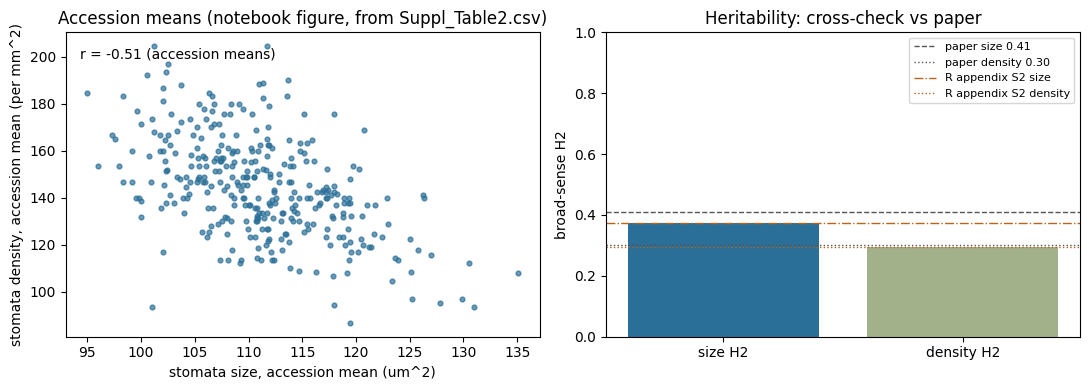

saved: /content/stomata_repro/reproduced_relationships.png


In [ ]:
import matplotlib
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
if col_size and col_density and col_gen:
    m = t2.groupby(col_gen)[[col_size, col_density]].mean().dropna()
    axes[0].scatter(m[col_size], m[col_density], s=12, alpha=0.7, c="#2a6f97")
    axes[0].set_xlabel("stomata size, accession mean (um^2)")
    axes[0].set_ylabel("stomata density, accession mean (per mm^2)")
    axes[0].set_title("Accession means (notebook figure, from Suppl_Table2.csv)")
    r = gcorr("size", "density")
    if r is not None:
        axes[0].text(0.03, 0.95, f"r = {r:+.2f} (accession means)", transform=axes[0].transAxes, va="top")

labels, vals = [], []
if h2.get("size") is not None: labels.append("size H2"); vals.append(h2["size"])
if h2.get("density") is not None: labels.append("density H2"); vals.append(h2["density"])
if labels:
    axes[1].bar(labels, vals, color=["#2a6f97", "#a3b18a"])
    axes[1].axhline(0.41, ls="--", lw=1, color="#555", label="paper size 0.41")
    axes[1].axhline(0.30, ls=":", lw=1, color="#555", label="paper density 0.30")
    if r_h2_size is not None: axes[1].axhline(r_h2_size, ls="-.", lw=1, color="#b5651d", label="R appendix S2 size")
    if r_h2_density is not None: axes[1].axhline(r_h2_density, ls=":", lw=1, color="#b5651d", label="R appendix S2 density")
    axes[1].set_ylim(0, 1)
    axes[1].set_ylabel("broad-sense H2")
    axes[1].set_title("Heritability: cross-check vs paper")
    axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(WORK / "reproduced_relationships.png", dpi=130)
plt.show()
print("saved:", WORK / "reproduced_relationships.png")

## 9. Interpretation and limits

**What this notebook establishes (one statistical demonstration):** using the authors' Appendix S2 R
code with input tables rebuilt from the published Dryad supplement, the broad-sense heritability of
stomata size and density, the trait GLMs by region of origin, the δ¹³C GLMs, and the climatic-PC GLMs
are executed on the published accession set, with an independent Python cross-check of the
heritabilities and correlations.

**What it does not establish:** the genetic-PC covariates (`pc1`–`pc20`) and the `Images` cofactor are
not in the published tables, so GLMs run here omit them (the paper notes δ¹³C–climate correlations are
confounded with population structure); the QST–FST, GWAS-allele and imaging-validation sections of
Appendix S2 need unpublished inputs and were skipped; no dataset-level GWAS/MTMM result is verified.
A single successful run of published aggregate tables does not verify the paper's full result set.
Free-tier Colab availability and durations vary.

**Provenance:** Dryad `doi:10.5061/dryad.n068q74` (CSV digests checked against Dryad API records),
PMC7611081 supplementary package (Europe PMC supplementary-file service). The notebook uses no private
API and no credentials.

**検証の限界（日本語）:** 遺伝子型主成分や`Images`共変量は公開表にないため、ここでのGLMはそれらを
除いて実行しています。QST-FST・GWASアレル・画像検証のセクションは未公開入力のためスキップしました。
公開表を用いた単一実行は論文の全結果の検証ではありません。